Week 4:
Post on brightspace
- What the heck is going with the timestamps??? (cleaning needed?)
- What is unmarked data versus hand at rest
- How/were are the channels placed, which muscle 

- Lets do some code and stats on that --> bar charts / histograms
- Lets find missing data? Zeros or NaN values
- For some ML models: one hot encoding needed
- For some ML models: normalization
- 50% feature (making features)

Week 5: 50% feature (analyze features / filter), Linear regression, SVM, Random Forest, 
Week 6: CNN, TS2Vec 
Week 7: compare and stuff
Week 8: Troubleshouting

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.signal import welch
import numpy as np

In [110]:
# ============================================================
# 0. SETUP
# ============================================================
df = pd.read_csv("Project_Data_EE4C12_S&S_EMG.csv")

# Work on a copy so the original dataframe remains unchanged
data = df.copy()

emg_channels = [
    "channel1", "channel2", "channel3", "channel4",
    "channel5", "channel6", "channel7", "channel8"
]


In [111]:
# ============================================================
# 1. BASIC DATASET OVERVIEW
# ============================================================

print("=" * 70)
print("1. DATASET OVERVIEW")
print("=" * 70)

print(f"Rows:             {len(data):,}")
print(f"Columns:          {data.shape[1]}")
print(f"Persons:          {data['label'].nunique()}")
print(f"Gestures:         {data['class'].nunique()}")
print(f"EMG channels:     {len(emg_channels)}")

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


1. DATASET OVERVIEW
Rows:             4,237,907
Columns:          11
Persons:          36
Gestures:         8
EMG channels:     8

First 5 rows:


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1



Last 5 rows:


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
4237902,50962,0.00001,-0.00001,-0.00002,-0.00004,-0.00012,0.0,0.00002,0.00002,0,36
4237903,50963,0.00001,-0.00001,-0.00002,-0.00004,-0.00012,0.0,0.00002,0.00002,0,36
4237904,50964,0.00001,-0.00001,-0.00002,-0.00004,-0.00012,0.0,0.00002,0.00002,0,36
4237905,50965,0.00001,-0.00001,-0.00002,-0.00004,-0.00012,0.0,0.00002,0.00002,0,36
4237906,50966,0.00001,-0.00001,-0.00002,-0.00004,-0.00012,0.0,0.00002,0.00002,0,36



2. DUPLICATES, MISSING AND ZERO VALUES
Duplicate rows: 0
Duplicate percentage: 0.0000%


,dtype,missing_n,missing_%,zero_n,zero_%,unique_n
time,int64,0,0.0,1,0.000024,84830
channel1,float64,0,0.0,530973,12.529133,256
channel2,float64,0,0.0,455122,10.739311,256
channel3,float64,0,0.0,360167,8.498700,256
channel4,float64,0,0.0,317040,7.481051,256
channel5,float64,0,0.0,300657,7.094469,256
channel6,float64,0,0.0,359680,8.487208,256
channel7,float64,0,0.0,500267,11.804577,256
channel8,float64,0,0.0,532891,12.574391,256
class,int64,0,0.0,2725157,64.304313,8


Rows containing ≥1 missing value: 0 (0.00%)
Rows containing ≥1 zero value: 3,302,884 (77.94%)

Number of gaps: 130911


,label,time_after_gap,time_step,missing_values
1,1,5,4.0,3.0
28,1,33,2.0,1.0
31,1,45,10.0,9.0
32,1,47,2.0,1.0
72,1,89,3.0,2.0
...,...,...,...,...
4237786,36,50839,3.0,2.0
4237831,36,50885,2.0,1.0
4237832,36,50890,5.0,4.0
4237873,36,50932,2.0,1.0


Maximum gap size: 13826


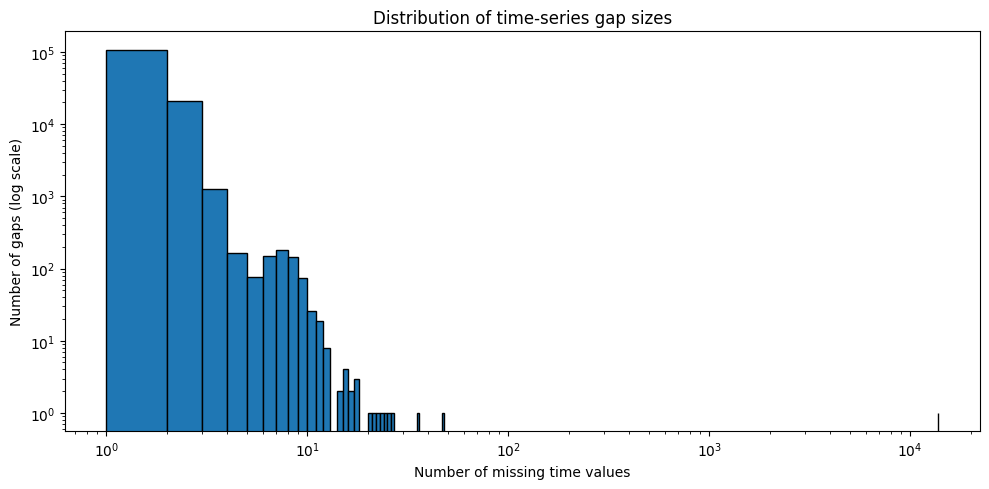

In [112]:
# ============================================================
# 2. DUPLICATES, MISSING AND ZERO VALUES
# ============================================================
print("\n" + "=" * 70)
print("2. DUPLICATES, MISSING AND ZERO VALUES")
print("=" * 70)

duplicate_n = data.duplicated().sum()

print(f"Duplicate rows: {duplicate_n:,}")
print(f"Duplicate percentage: {duplicate_n / len(data) * 100:.4f}%")


data_quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_n": data.isna().sum(),
    "missing_%": data.isna().mean() * 100,
    "zero_n": (data == 0).sum(),
    "zero_%": (data == 0).mean() * 100,
    "unique_n": data.nunique()
})

display(data_quality)

# Rows with missing values
rows_with_missing = data.isna().any(axis=1)

# Rows with zero values
rows_with_zero = (data == 0).any(axis=1)

print(
    f"Rows containing ≥1 missing value: "
    f"{rows_with_missing.sum():,} "
    f"({rows_with_missing.mean() * 100:.2f}%)"
)

print(
    f"Rows containing ≥1 zero value: "
    f"{rows_with_zero.sum():,} "
    f"({rows_with_zero.mean() * 100:.2f}%)"
)


# Difference between consecutive time values
data["time_diff"] = (
    data.groupby("label")["time"]
        .diff()
)

# A gap only exists when time increases by more than 1
data["is_gap"] = data["time_diff"] > 1


# ------------------------------------------------------------
# GAP SUMMARY
# ------------------------------------------------------------

gaps = data[data["is_gap"]].copy()

print(f"\nNumber of gaps: {len(gaps)}")


# ------------------------------------------------------------
# GAP DETAILS
# ------------------------------------------------------------

gaps["missing_values"] = gaps["time_diff"] - 1

gap_details = gaps[
    [
        "label",
        "time",
        "time_diff",
        "missing_values"
    ]
].copy()

gap_details = gap_details.rename(
    columns={
        "time": "time_after_gap",
        "time_diff": "time_step"
    }
)

display(gap_details)

print(f"Maximum gap size: {int(gaps['missing_values'].max())}")

plt.figure(figsize=(10, 5))

plt.hist(
    gaps["missing_values"],
    bins=range(
        int(gaps["missing_values"].min()),
        int(gaps["missing_values"].max()) + 2
    ),
    edgecolor="black"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of missing time values")
plt.ylabel("Number of gaps (log scale)")
plt.title("Distribution of time-series gap sizes")

plt.tight_layout()
plt.show()

Note: there is a single measurement with t=0

In [113]:
zero_indices = data.index[data["time"] == 0]

for idx in zero_indices:

    print(
        data.loc[
            max(0, data.index.get_loc(idx) - 2):
            data.index.get_loc(idx) + 2
        ]
    )

          time  channel1  channel2  channel3  channel4  channel5  channel6  \
3430829  53724  -0.00003  -0.00007  -0.00003  -0.00003  -0.00011  -0.00005   
3430830  53725  -0.00003  -0.00007  -0.00003  -0.00003  -0.00011  -0.00005   
3430831      0  -0.00001  -0.00002  -0.00001  -0.00005  -0.00006  -0.00004   
3430832      3  -0.00002   0.00000   0.00011   0.00006  -0.00013  -0.00004   
3430833      4  -0.00002   0.00000   0.00011   0.00006  -0.00013  -0.00004   

         channel7  channel8  class  label  time_diff  is_gap  
3430829  -0.00003  -0.00002      0     29        1.0   False  
3430830  -0.00003  -0.00002      0     29        1.0   False  
3430831  -0.00001  -0.00002      0     30        NaN   False  
3430832   0.00000   0.00001      0     30        3.0    True  
3430833   0.00000   0.00001      0     30        1.0   False  



3. NUMBER OF SAMPLES PER PERSON AND PER SERIES
Detected series: 72
Expected series: 72
✓ Every person has exactly 2 series.


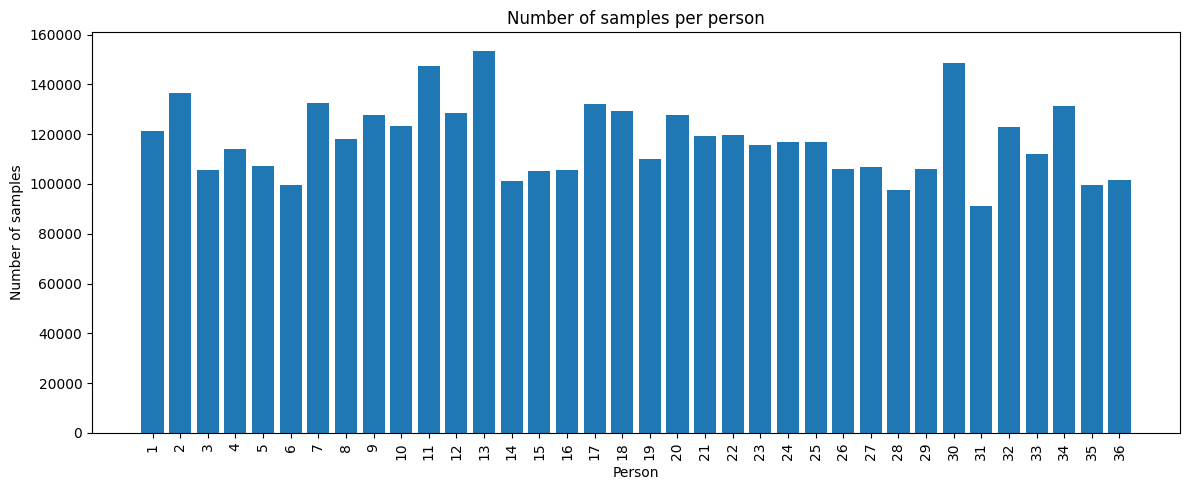


Statistics: samples per person
----------------------------------------------------------------------
count        36.000000
mean     117719.638889
std       15058.550390
min       91023.000000
25%      105936.500000
50%      116843.500000
75%      128027.500000
max      153240.000000
Name: count, dtype: float64


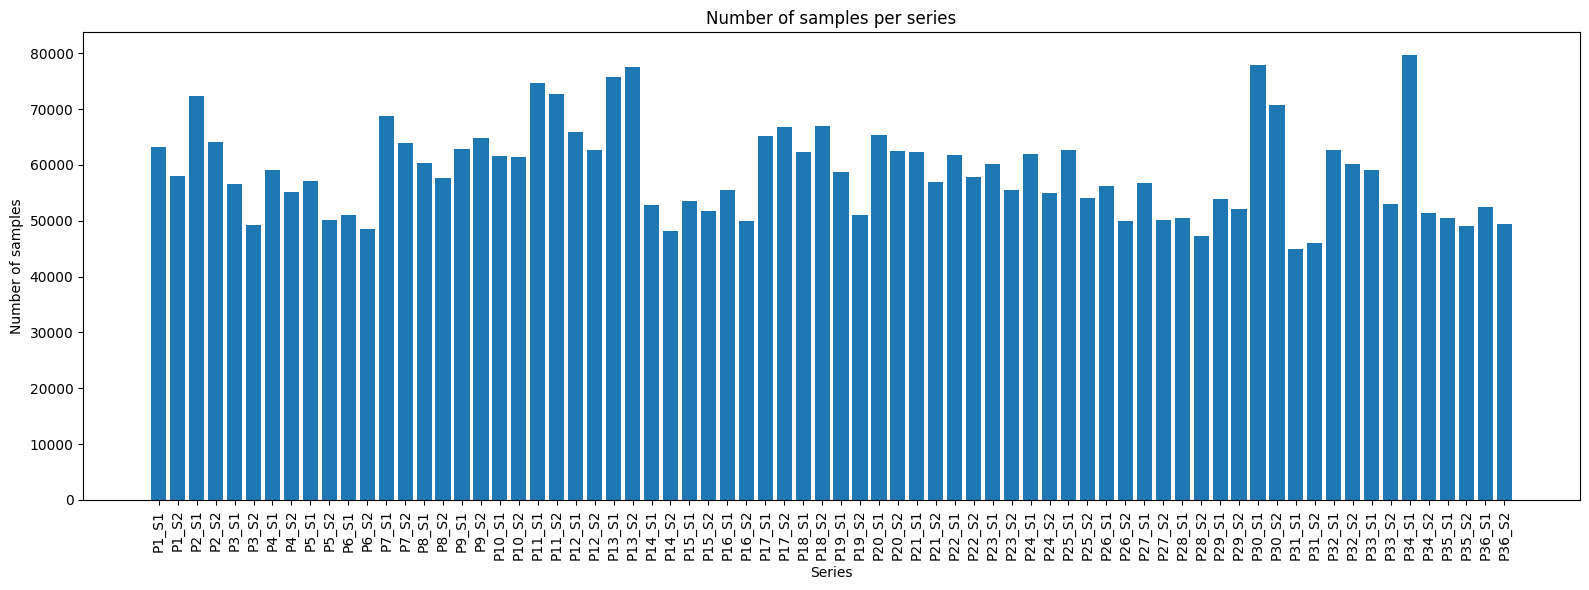


Statistics: samples per series
----------------------------------------------------------------------
count       72.000000
mean     58859.819444
std       8200.273866
min      44927.000000
25%      52023.000000
50%      57907.500000
75%      62876.500000
max      79764.000000
Name: n_samples, dtype: float64


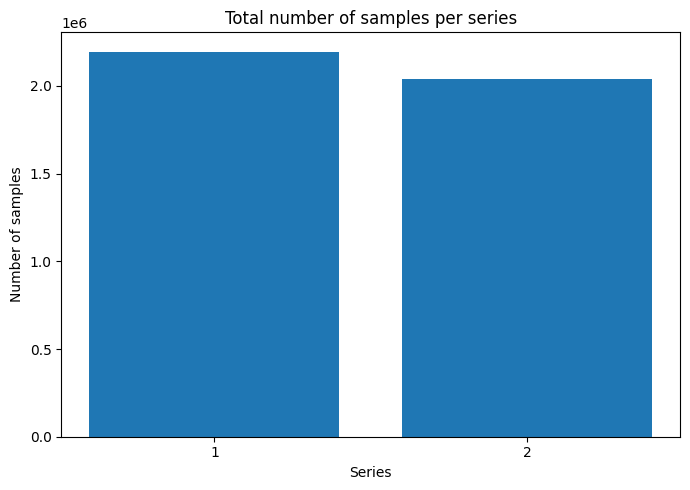

In [114]:
# ============================================================
# 3. NUMBER OF SAMPLES PER PERSON AND PER SERIES
# ============================================================

print("\n" + "=" * 70)
print("3. NUMBER OF SAMPLES PER PERSON AND PER SERIES")
print("=" * 70)

# ------------------------------------------------------------
# A. IDENTIFY THE SERIES
# ------------------------------------------------------------

data = data.sort_index()

data["new_series"] = (
    data.groupby("label")["time"]
        .diff()
        .fillna(1)
        <= 0
)

# First row of every person must start a series
data["new_series"] = (
    data["new_series"]
    | data.groupby("label").cumcount().eq(0)
)

# Assign series number within each person
data["series"] = (
    data.groupby("label")["new_series"]
        .cumsum()
        .astype(int)
)

data.drop(columns="new_series", inplace=True)


series_per_person = data.groupby("label")["series"].nunique()

print(f"Detected series: {data.groupby(['label', 'series']).ngroups}")
print(f"Expected series: {36 * 2}")



persons_not_two = series_per_person[series_per_person != 2]

if len(persons_not_two) == 0:
    print("✓ Every person has exactly 2 series.")
else:
    print("⚠ Persons with != 2 series:")
    display(persons_not_two)


# ------------------------------------------------------------
# B. NUMBER OF SAMPLES PER PERSON
# ------------------------------------------------------------

person_counts = (
    data["label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

plt.bar(
    person_counts.index.astype(str),
    person_counts.values
)

plt.xlabel("Person")
plt.ylabel("Number of samples")
plt.title("Number of samples per person")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


print("\nStatistics: samples per person")
print("-" * 70)
print(person_counts.describe())


# ------------------------------------------------------------
# C. NUMBER OF SAMPLES PER SERIES
# ------------------------------------------------------------

series_counts = (
    data.groupby(["label", "series"])
         .size()
         .reset_index(name="n_samples")
)

# Give every series a unique identifier for the plot
series_counts["series_id"] = (
    "P" + series_counts["label"].astype(str)
    + "_S" + series_counts["series"].astype(str)
)


plt.figure(figsize=(16, 6))

plt.bar(
    series_counts["series_id"],
    series_counts["n_samples"]
)

plt.xlabel("Series")
plt.ylabel("Number of samples")
plt.title("Number of samples per series")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


print("\nStatistics: samples per series")
print("-" * 70)
print(series_counts["n_samples"].describe())


# ------------------------------------------------------------
# D. SERIES 1 VS SERIES 2
# ------------------------------------------------------------

series_number_counts = (
    data.groupby("series")
        .size()
)

plt.figure(figsize=(7, 5))

plt.bar(
    series_number_counts.index.astype(str),
    series_number_counts.values
)

plt.xlabel("Series")
plt.ylabel("Number of samples")
plt.title("Total number of samples per series")

plt.tight_layout()
plt.show()




4. HAND GESTURES


,n_samples
class,
0,2725157
1,250055
2,243193
3,249494
4,251570
5,251733
6,253009
7,13696


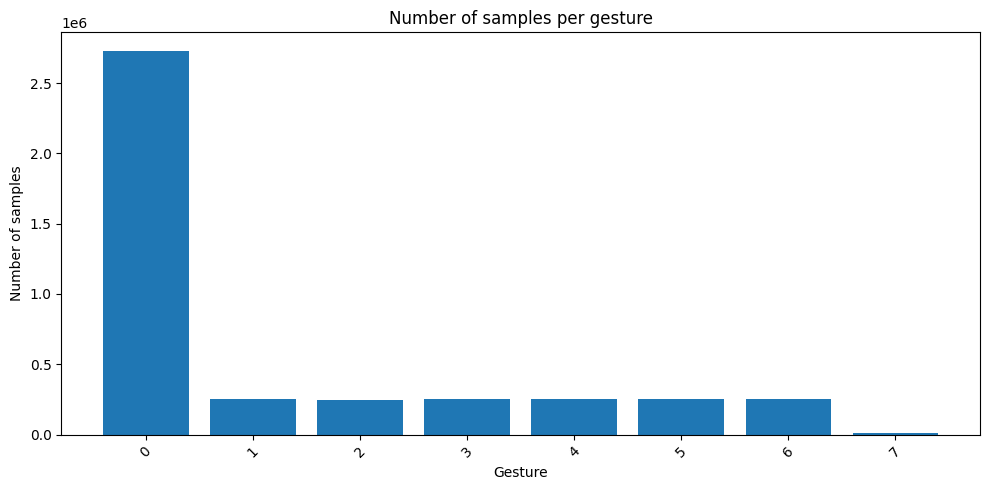

class,0,1,2,3,4,5,6,7
label,,,,,,,,
1,78682,7311,6806,7329,6824,7075,7143,0
2,94654,7140,6777,6815,6812,6856,7372,0
3,67770,6443,6301,6486,6421,6278,6086,0
4,72578,6471,6598,6875,7193,7423,7060,0
5,68057,6506,6806,6874,6724,6098,6183,0
6,61128,5814,6243,6663,6688,7094,5989,0
7,82641,7523,7651,8383,8923,8414,9105,0
8,80264,6468,6537,5939,6027,6237,6476,0
9,90407,7083,6019,5838,5776,6050,6474,0


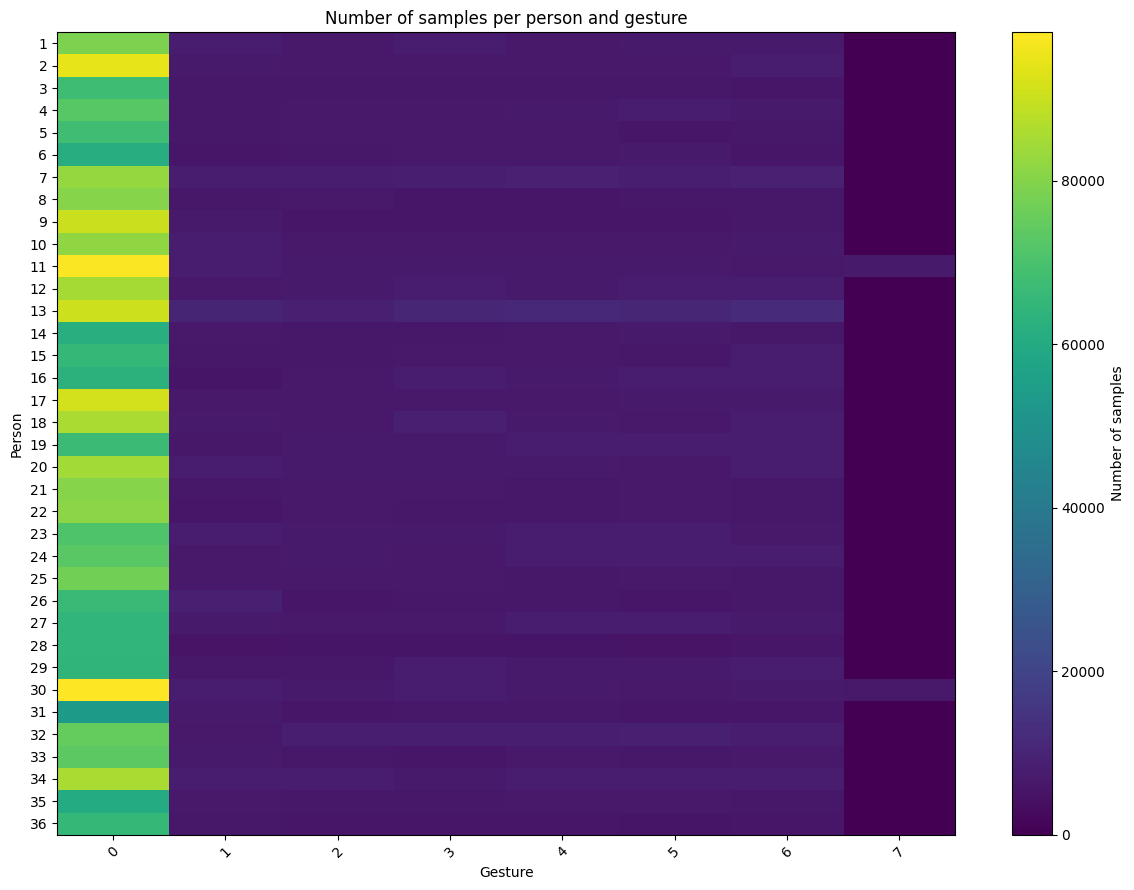

   label  series  gesture_block  class  n_samples
0      1       1              1      0       2287
1      1       1              2      1       2115
2      1       1              3      0       2022
3      1       1              4      2       1794
4      1       1              5      0       4316


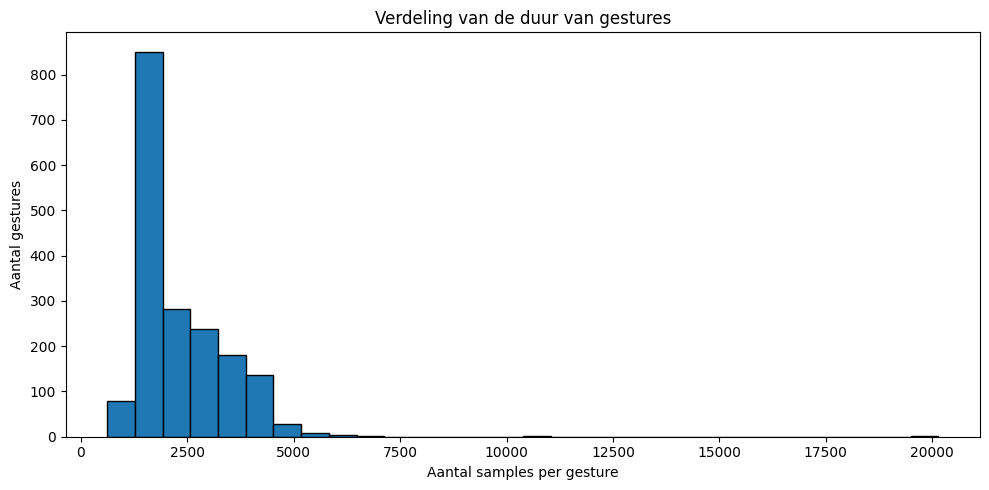

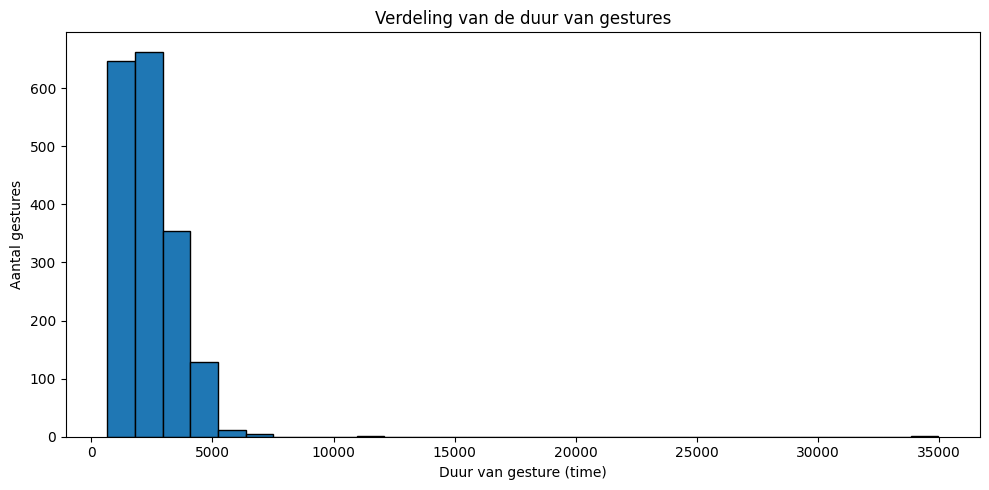

In [115]:
# ============================================================
# 4. HAND GESTURES
# ============================================================

print("\n" + "=" * 70)
print("4. HAND GESTURES")
print("=" * 70)

gesture_counts = data["class"].value_counts().sort_index()

display(gesture_counts.to_frame("n_samples"))

plt.figure(figsize=(10, 5))

plt.bar(
    gesture_counts.index.astype(str),
    gesture_counts.values
)

plt.xlabel("Gesture")
plt.ylabel("Number of samples")
plt.title("Number of samples per gesture")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

person_gesture = pd.crosstab(
    data["label"],
    data["class"]
)

display(person_gesture)

plt.figure(figsize=(12, 9))

plt.imshow(
    person_gesture,
    aspect="auto"
)

plt.colorbar(label="Number of samples")

plt.xlabel("Gesture")
plt.ylabel("Person")
plt.title("Number of samples per person and gesture")

plt.xticks(
    range(len(person_gesture.columns)),
    person_gesture.columns,
    rotation=45
)

plt.yticks(
    range(len(person_gesture.index)),
    person_gesture.index
)

plt.tight_layout()
plt.show()



#Code for duration of hand gesture
data["new_gesture"] = (
    data.groupby(["label", "series"])["class"]
        .transform(lambda x: x != x.shift())
)

data["gesture_block"] = (
    data.groupby(["label", "series"])["new_gesture"]
        .cumsum()
)

gesture_durations = (
    data.groupby(["label", "series", "gesture_block", "class"])
        .size()
        .reset_index(name="n_samples")
)

print(gesture_durations.head())


plt.figure(figsize=(10, 5))

plt.hist(
    gesture_durations["n_samples"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Aantal samples per gesture")
plt.ylabel("Aantal gestures")
plt.title("Verdeling van de duur van gestures")

plt.tight_layout()
plt.show()

gesture_durations["time_duration"] = (
    gesture_durations.groupby(["label", "series"])["n_samples"]
    .transform(lambda x: x)  # alleen voor behoud van structuur
)

gesture_time = (
    data.groupby(["label", "series", "gesture_block", "class"])
        .agg(
            start_time=("time", "first"),
            end_time=("time", "last"),
            n_samples=("time", "size")
        )
        .reset_index()
)

gesture_time["time_duration"] = (
    gesture_time["end_time"] - gesture_time["start_time"]
)

plt.figure(figsize=(10, 5))

plt.hist(
    gesture_time["time_duration"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Duur van gesture (time)")
plt.ylabel("Aantal gestures")
plt.title("Verdeling van de duur van gestures")

plt.tight_layout()
plt.show()

Note: only 2 people perform gesture 7


5. EMG STATISTICS


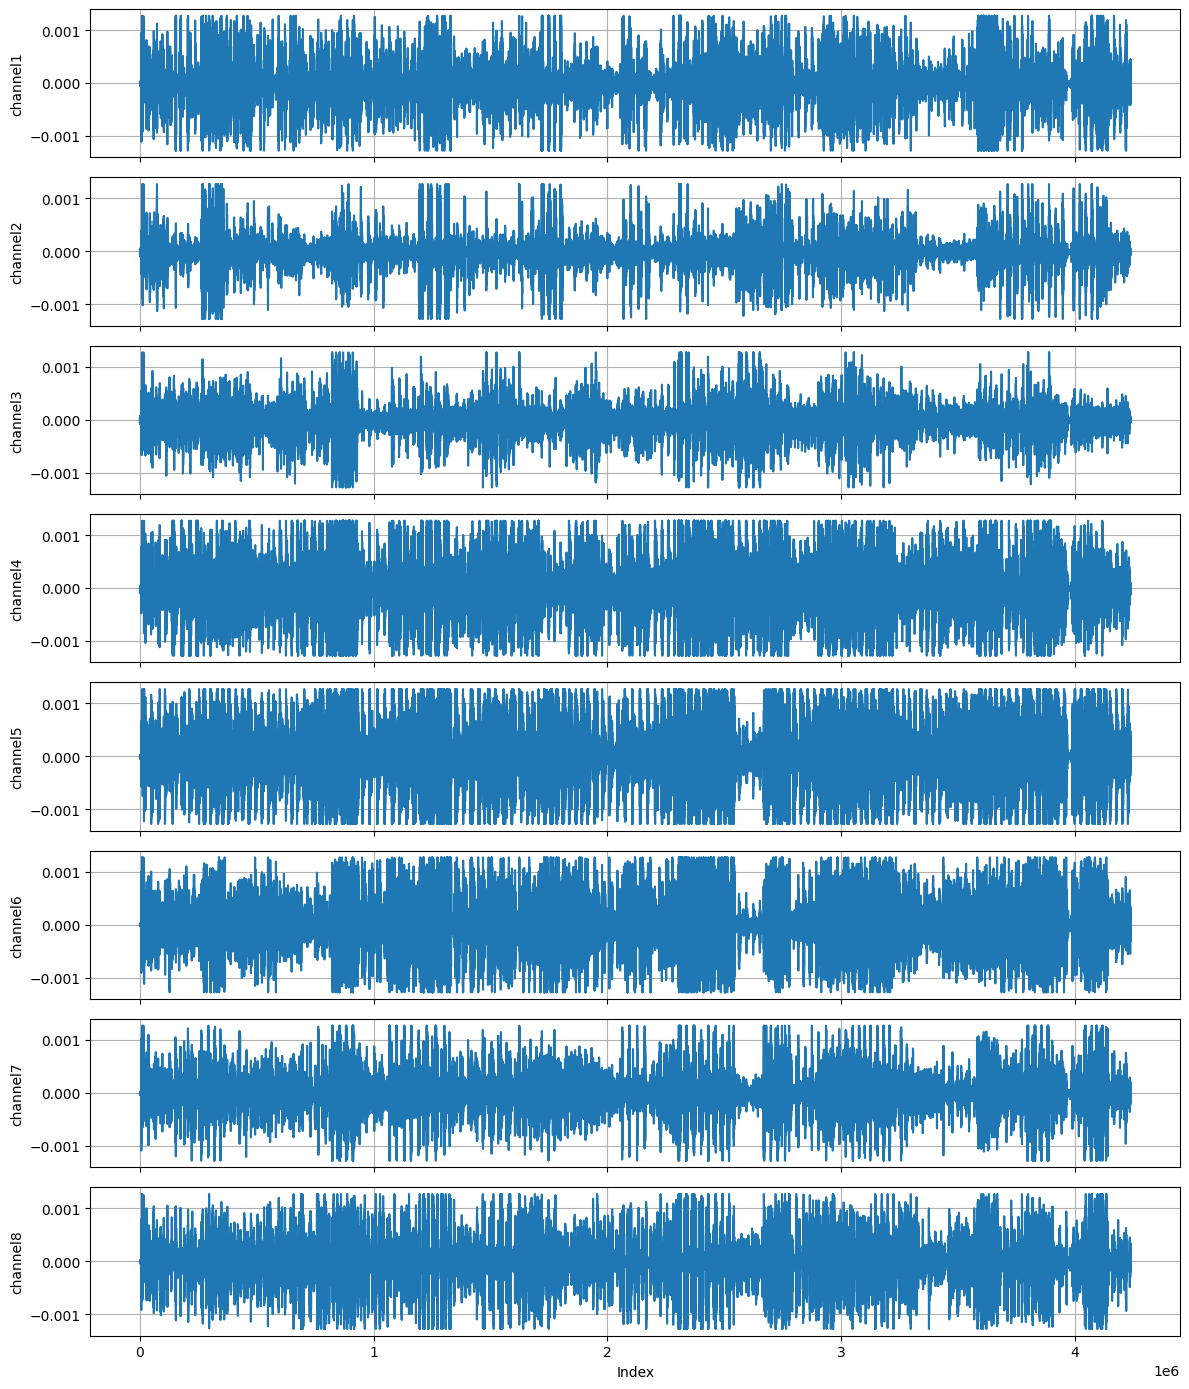

,count,mean,std,min,25%,50%,75%,max
channel1,4237907.0,-0.000008,0.000163,-0.00128,-0.00003,-0.00001,0.00002,0.00127
channel2,4237907.0,-0.000009,0.000119,-0.00128,-0.00004,-0.00001,0.00002,0.00127
channel3,4237907.0,-0.000010,0.000124,-0.00128,-0.00004,-0.00001,0.00003,0.00127
channel4,4237907.0,-0.000010,0.000226,-0.00128,-0.00006,-0.00001,0.00004,0.00127
channel5,4237907.0,-0.000016,0.000272,-0.00128,-0.00008,-0.00001,0.00005,0.00127
channel6,4237907.0,-0.000011,0.000215,-0.00128,-0.00006,-0.00001,0.00003,0.00127
channel7,4237907.0,-0.000009,0.000153,-0.00128,-0.00004,-0.00001,0.00002,0.00127
channel8,4237907.0,-0.000010,0.000172,-0.00128,-0.00003,-0.00001,0.00001,0.00127


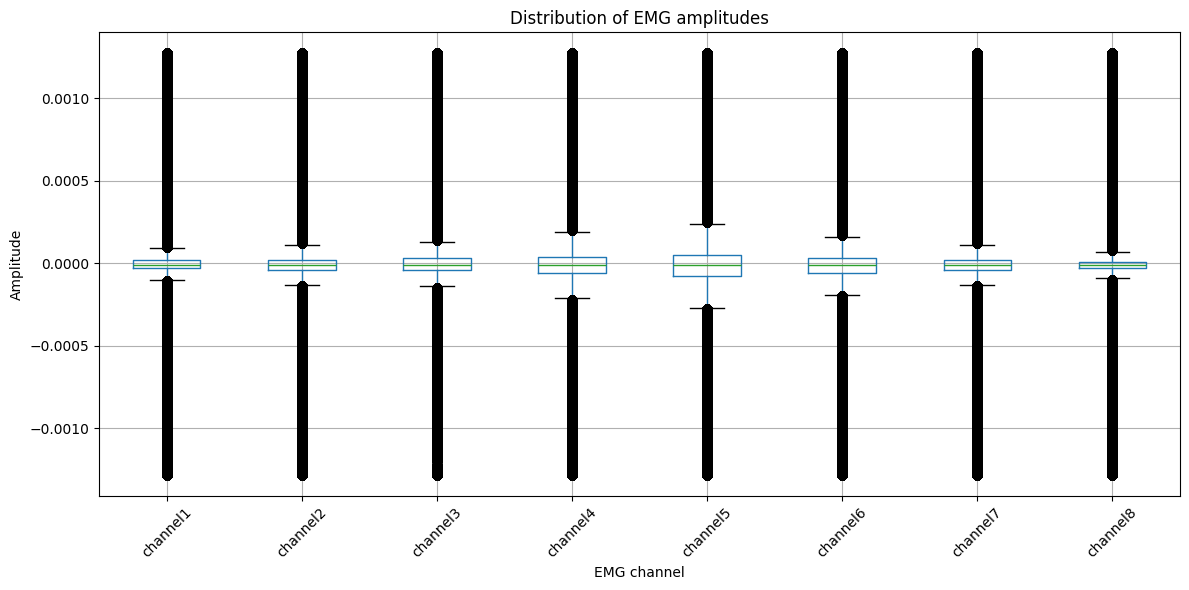

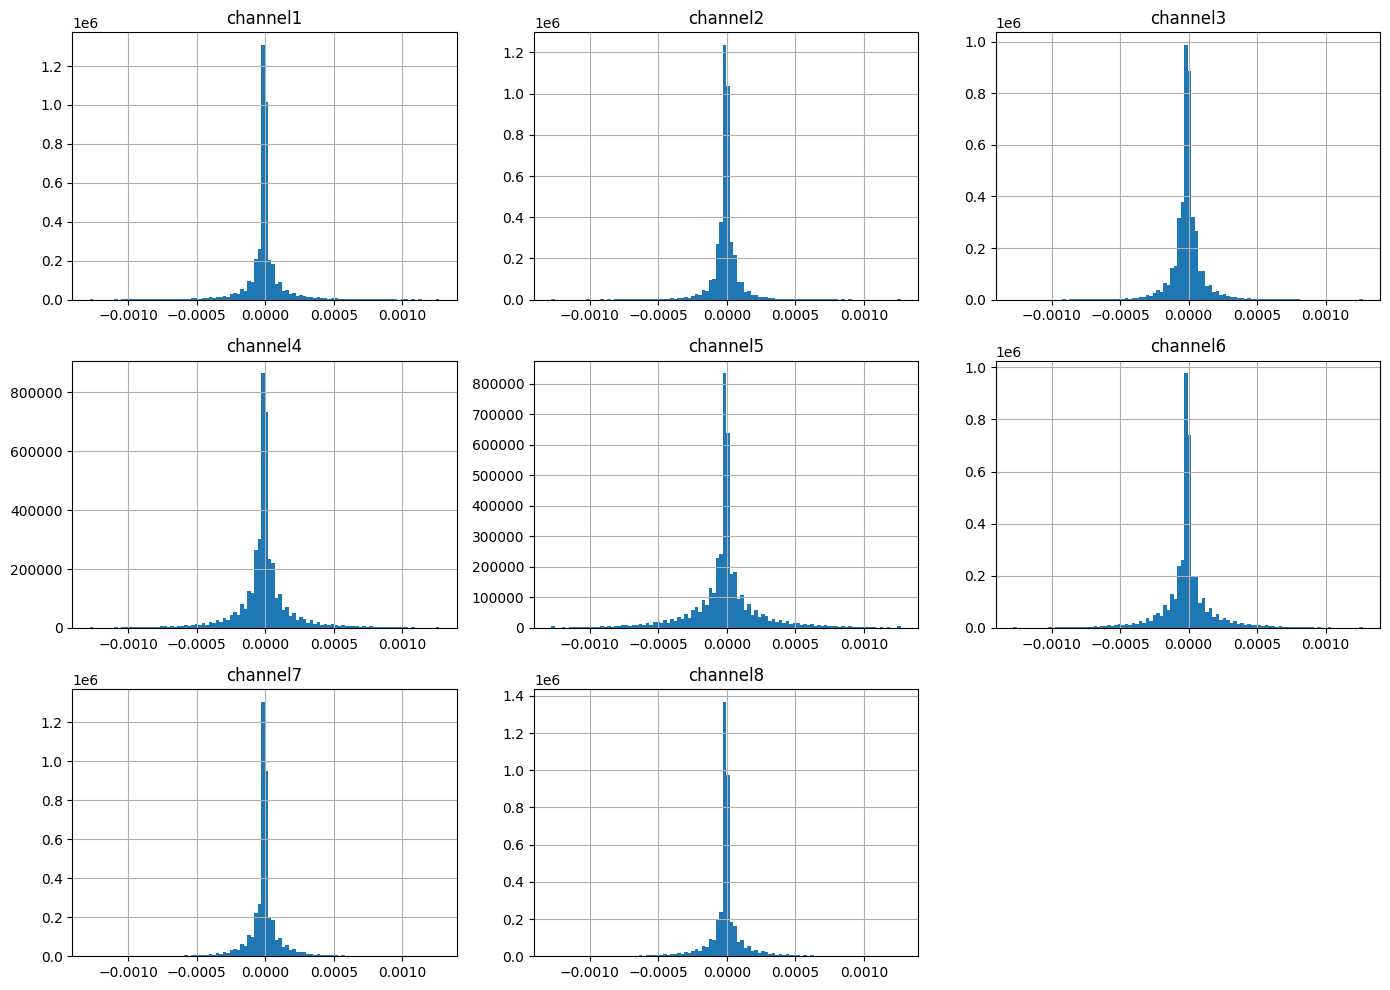

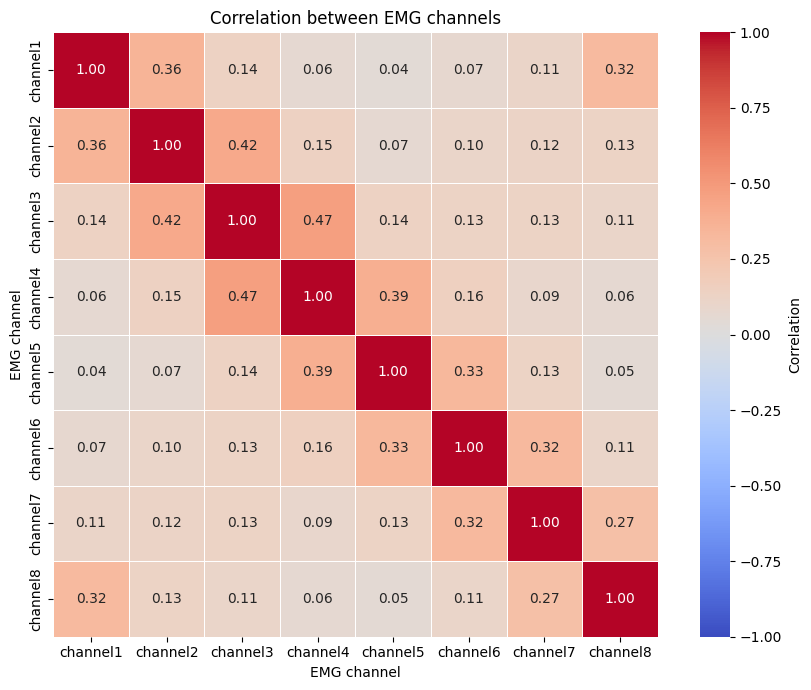

In [116]:
# ============================================================
# 5. EMG STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("5. EMG STATISTICS")
print("=" * 70)

channels = [f"channel{i}" for i in range(1, 9)]

fig, axes = plt.subplots(8, 1, figsize=(12, 14), sharex=True)

for i, channel in enumerate(channels):
    axes[i].plot(df[channel])
    axes[i].set_ylabel(channel)
    axes[i].grid(True)

axes[-1].set_xlabel("Index")
plt.tight_layout()
plt.show()

emg_stats = data[emg_channels].describe().T

display(emg_stats)


plt.figure(figsize=(12, 6))

data[emg_channels].boxplot()

plt.xlabel("EMG channel")
plt.ylabel("Amplitude")
plt.title("Distribution of EMG amplitudes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

data[emg_channels].hist(
    bins=100,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

correlation = data[emg_channels].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,       
    fmt=".2f",     
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation between EMG channels")
plt.xlabel("EMG channel")
plt.ylabel("EMG channel")

plt.tight_layout()
plt.show()




In [119]:
"""
X = df[emg_channels]

# Split eerst
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

# Fit scaler alleen op training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
"""

'\nX = df[emg_channels]\n\n# Split eerst\nX_train, X_test = train_test_split(\n    X,\n    test_size=0.2,\n    random_state=42\n)\n\n# Fit scaler alleen op training data\nscaler = StandardScaler()\n\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n'